This file contains codes to replicate:
- Fig. 1
- Fig. 2
- Fig. 3
- Table 1
- Table 2
- Table 4

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import helper
from scipy.stats import norm
from pathlib import Path

Loading library list...
Done


## Save Plots and Figures

In [2]:
# Save plots
save_plt = False

# Save tables
save_table = False

## Set Ticker Symbols and Time Range

In [3]:
# Set array with ticker symbols
tickers = ['APA', 'COP', 'CVX', 'DVN', 'EOG', 'HAL', 'MRO', 'OXY', 'VLO', 'XOM']

# Set start and end years
start_year = 2005
end_year   = 2022

## Upload CRSP Stock Data

In [4]:
# Upload CRSP stock data as dictionary
ret_tickers = helper.crsp_data(tickers, start_year, end_year)

# Visualize
ret_tickers['APA'].head()

,ticker,permno,hsiccd,shrcd,date,prc,ret,log_ret,vol,year
27187,APA,39490,1311,11,2005-01-03,48.28,-0.045284,-0.046341,3084100.0,2005
27188,APA,39490,1311,11,2005-01-04,47.89,-0.008078,-0.008111,3543600.0,2005
27189,APA,39490,1311,11,2005-01-05,47.73,-0.003341,-0.003347,3326600.0,2005
27190,APA,39490,1311,11,2005-01-06,48.5,0.016132,0.016003,3606200.0,2005
27191,APA,39490,1311,11,2005-01-07,48.19,-0.006392,-0.006413,1857700.0,2005


## Analyze the Distribution of Log-Returns (Fig. 1)

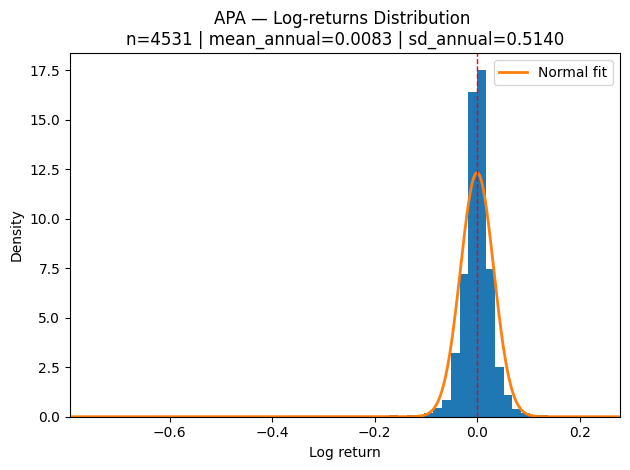

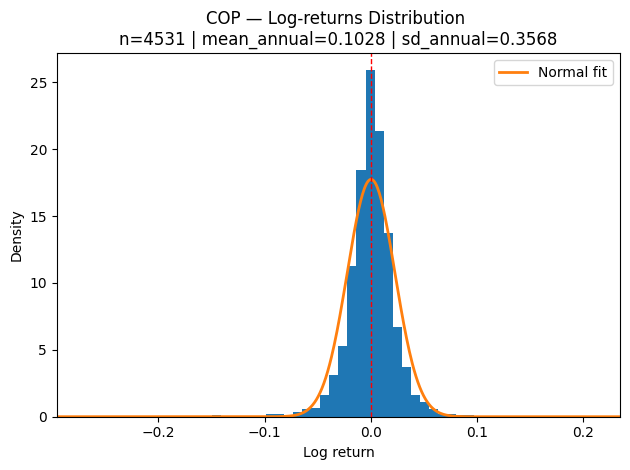

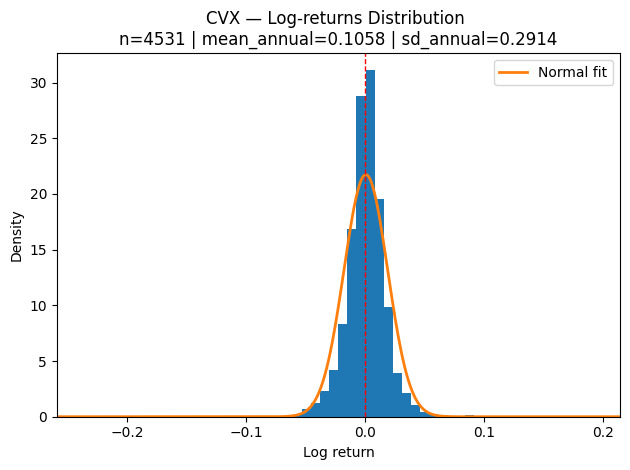

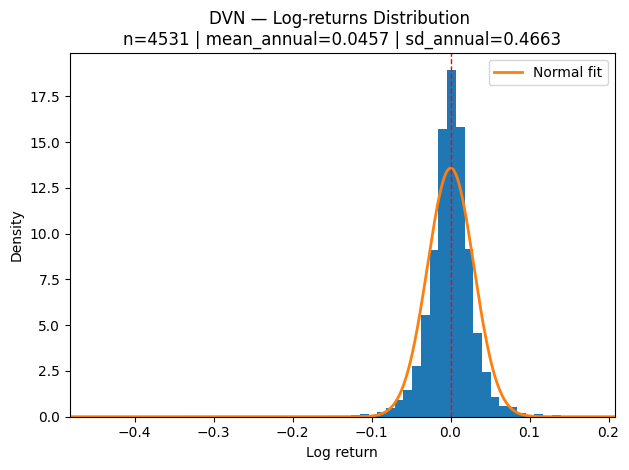

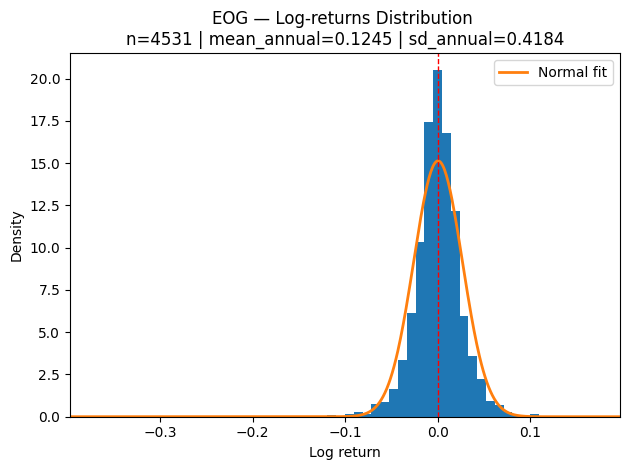

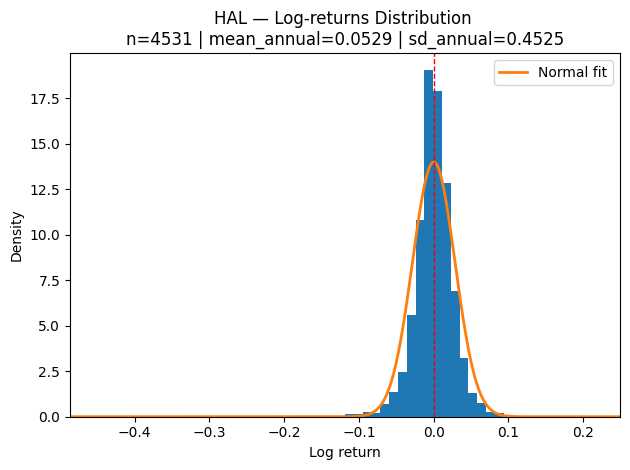

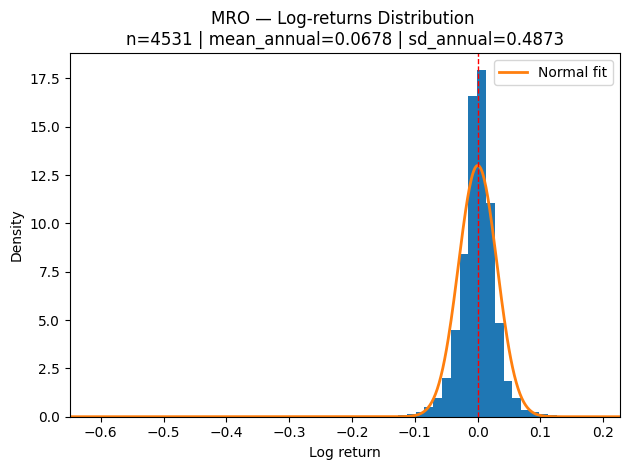

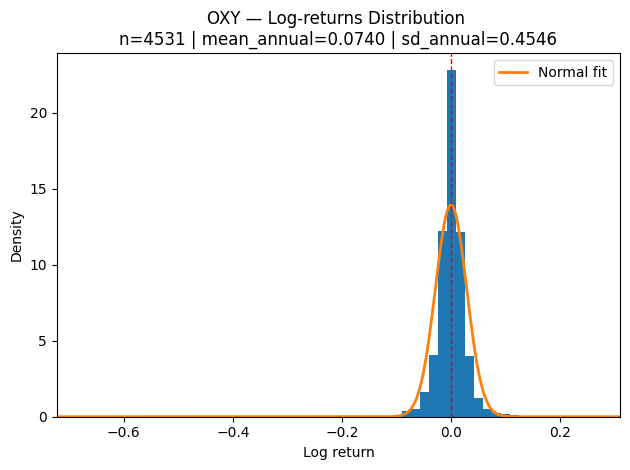

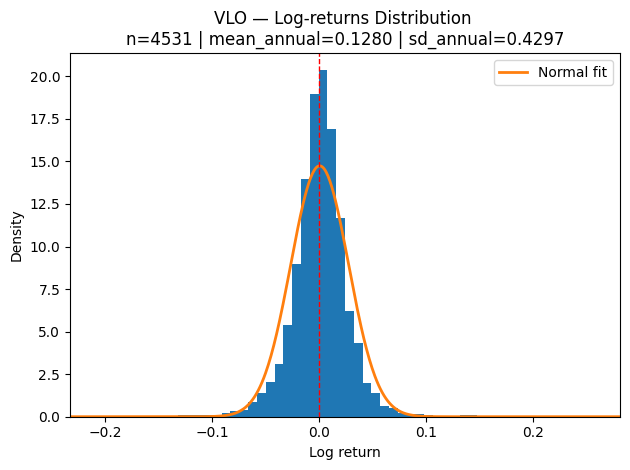

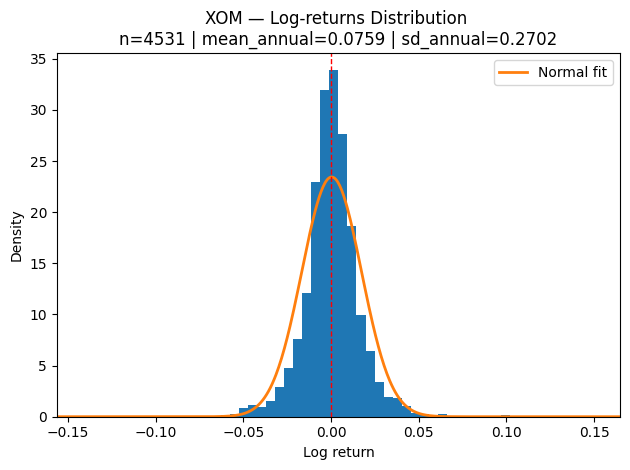

In [5]:
# Create list to collect summary statistics
stats_list = []

# Run loop to obtain data stats and plot histogram
for t in tickers:
    # Call each dataframe per ticker
    df = ret_tickers[t]
    
    # Define horizon of the plots
    xmin = df['log_ret'].min()
    xmax = df['log_ret'].max()
    pad = 0.02 * (xmax - xmin) if np.isfinite(xmax - xmin) else 0.0
    xmin_plot, xmax_plot = xmin - pad, xmax + pad
    
    # Stats
    mu_hat     = df['log_ret'].mean()         # mean
    sd_hat     = df['log_ret'].std(ddof=1)    # standard deviation 
    n_obs      = len(df['log_ret'])           # n of observations
    skew_hat   = df['log_ret'].skew()         # skewness
    kurt_exces = df['log_ret'].kurt()         # excess kurtosis (0 for normal)
    
    # Store stats in a separate dataframe
    stats_list.append({
        'ticker'      : t,
        'n_obs'       : n_obs,
        'mean'        : mu_hat,
        'sd'          : sd_hat,
        'skew'        : skew_hat,
        'kurt_excess' : kurt_exces
    })
    
    # Define a normal pdf
    lo = min(xmin_plot, df['log_ret'].min())
    hi = max(xmax_plot, df['log_ret'].max())
    xgrid = np.linspace(lo, hi, 600)
    ypdf  = norm.pdf(xgrid, loc=mu_hat, scale=sd_hat)
    
    # Plot
    fig = plt.figure()
    # Plot histogram with log-returns
    plt.hist(df['log_ret'], bins=60, density=True)
    
    # Plot normal pdf
    plt.plot(xgrid, ypdf, linewidth=2, label="Normal fit")
    # Set vertical line at zero
    plt.axvline(0.0, linewidth=1, color='red', linestyle="--")
    plt.xlim(xmin_plot, xmax_plot)
    
    # Set axis labels
    plt.xlabel('Log return')
    plt.ylabel('Density')
    
    # Set title
    plt.title(
        f"{t} — Log-returns Distribution \n"
        f"n={n_obs} | mean_annual={df['log_ret'].mean()*252:.4f} | sd_annual={df['log_ret'].std()*np.sqrt(252):.4f}"
    )
    
    # Set labels
    plt.legend()
    
    # Set layout
    plt.tight_layout()
    
    # Save if required
    if save_plt:
        # Set directory
        out_dir = Path("log_ret_hist")
        out_dir.mkdir(parents=True, exist_ok=True)
        # Save plot as a png in a directory
        fname = f"{str(t).upper()}.png"
        fig.savefig(out_dir / fname, dpi=300, bbox_inches="tight")
    
    # Show plots
    plt.show()
    plt.close(fig)

## Normality Test of Residuals (Table 1)

In [6]:
# Set a single dataframe from the dictionary
ret_df = pd.concat(ret_tickers, ignore_index=True)

# List to collect results
results = []
residuals = {}

# Run normality test by ticker
for tic, grp in ret_df.groupby('ticker'):
    # Store log-returns in a vector
    y = grp['log_ret']
    # Set a vector of ones (constant)
    X = np.ones(len(y))
    # Perform OLS regression
    ols_res = sm.OLS(y, X).fit()
    
    # Obtain residuals
    resid = ols_res.resid
    residuals[tic] = resid
    
    # Perform normality tests
    shapiro_p = stats.shapiro(resid)[1]            # Shapiro–Wilk
    jb_p      = stats.jarque_bera(resid)[1]        # Jarque–Bera
    skew_p    = stats.skewtest(resid)[1]           # D’Agostino skew
    kurt_p    = stats.kurtosistest(resid)[1]       # Excess kurtosis test

    results.append([tic, shapiro_p, jb_p, skew_p, kurt_p])
    
# Convert results to dataframe
norm_df = pd.DataFrame(results, columns=['ticker',
                                         'Shapiro_p',
                                         'JB_p',
                                         'Skew_p',
                                         'Kurt_p'])

# Round to six decimal cases
norm_df = norm_df.round(6)

# Save if requested
if save_table:
    # Save as a csv file
    norm_df.to_csv("resid_norm_test.csv", index=False)

# Visualize dataframe
norm_df

,ticker,Shapiro_p,JB_p,Skew_p,Kurt_p
0,APA,0.0,0.0,0.000000,0.0
1,COP,0.0,0.0,0.000000,0.0
2,CVX,0.0,0.0,0.000000,0.0
3,DVN,0.0,0.0,0.000000,0.0
4,EOG,0.0,0.0,0.000000,0.0
5,HAL,0.0,0.0,0.000000,0.0
6,MRO,0.0,0.0,0.000000,0.0
7,OXY,0.0,0.0,0.000000,0.0
8,VLO,0.0,0.0,0.000000,0.0
9,XOM,0.0,0.0,0.028174,0.0


## Observe Log-Returns Statistics (Table 2)

In [7]:
# Convert stats into dataframe
stats_df = pd.DataFrame(stats_list)

# Rename columns
stats_df.rename(columns={'mean':'mean_daily', 'sd':'sd_daily'}, inplace=True)

# Covert mean and std to annual
stats_df['mean_annual'] = stats_df['mean_daily'] * 252
stats_df['sd_annual']  = stats_df['sd_daily'] * np.sqrt(252)

# Drop daily mean and std
stats_df.drop(columns=["mean_daily", "sd_daily"], inplace=True)

# Round to six decimal places
stats_df = stats_df.round(6)

# Save if requested
if save_table:
    # Save as csv file
    stats_df.to_csv("log_ret_stats.csv", index=False)

# Visualize dataframe
stats_df

,ticker,n_obs,skew,kurt_excess,mean_annual,sd_annual
0,APA,4531,-3.281499,82.368707,0.008312,0.513991
1,COP,4531,-0.516516,13.459790,0.102799,0.356841
2,CVX,4531,-0.510262,21.789497,0.105838,0.291443
3,DVN,4531,-0.844400,18.823125,0.045719,0.466310
4,EOG,4531,-0.704348,14.371126,0.124506,0.418420
5,HAL,4531,-1.370295,24.510377,0.052857,0.452549
6,MRO,4531,-1.831154,44.040410,0.067785,0.487253
7,OXY,4531,-2.966998,88.095333,0.073960,0.454602
8,VLO,4531,-0.334123,8.781070,0.127987,0.429704
9,XOM,4531,-0.079891,10.106108,0.075888,0.270153


## Plot Log-Returns with Potential Jumps (Fig. 2)

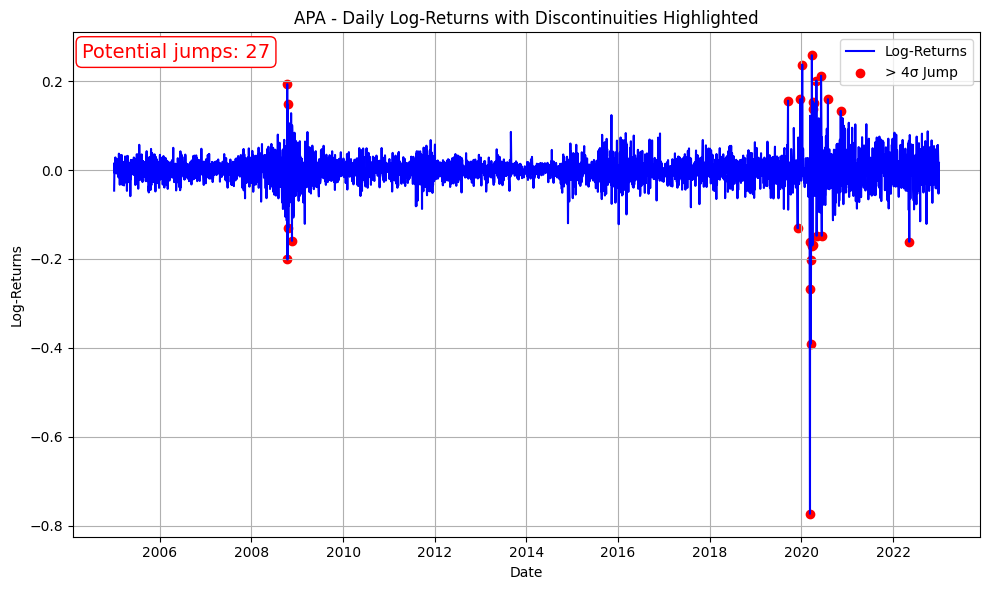

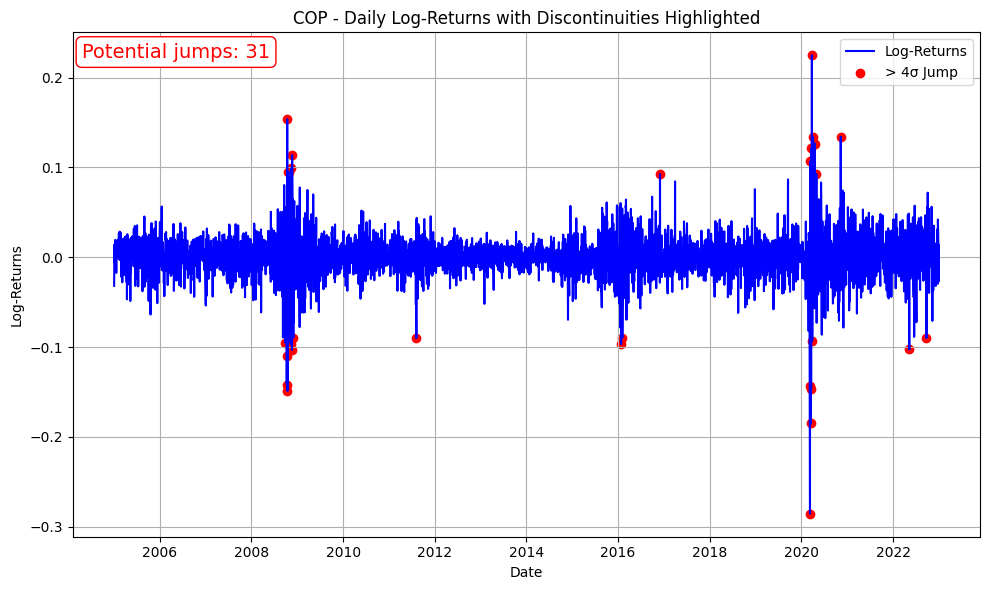

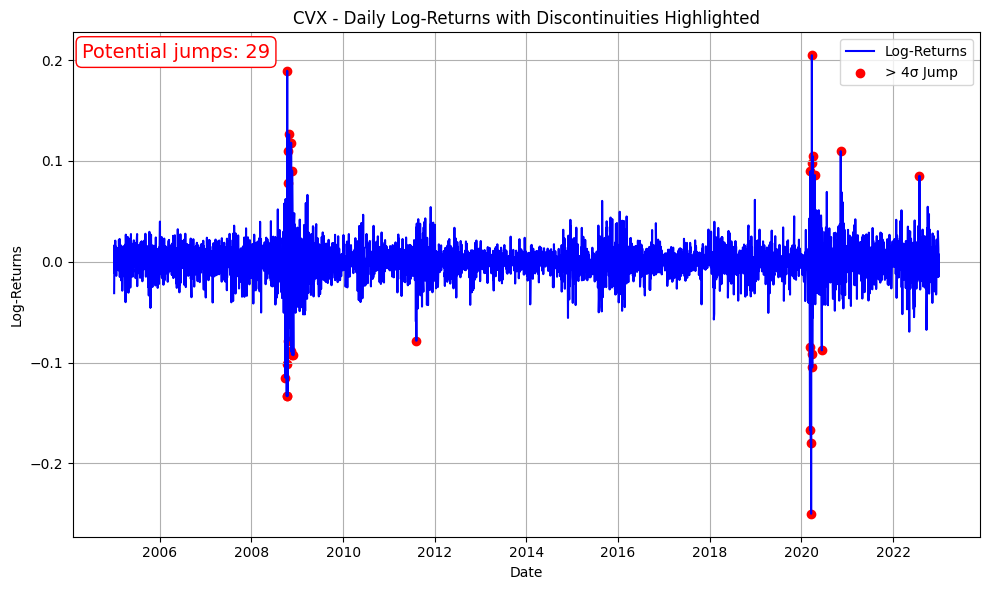

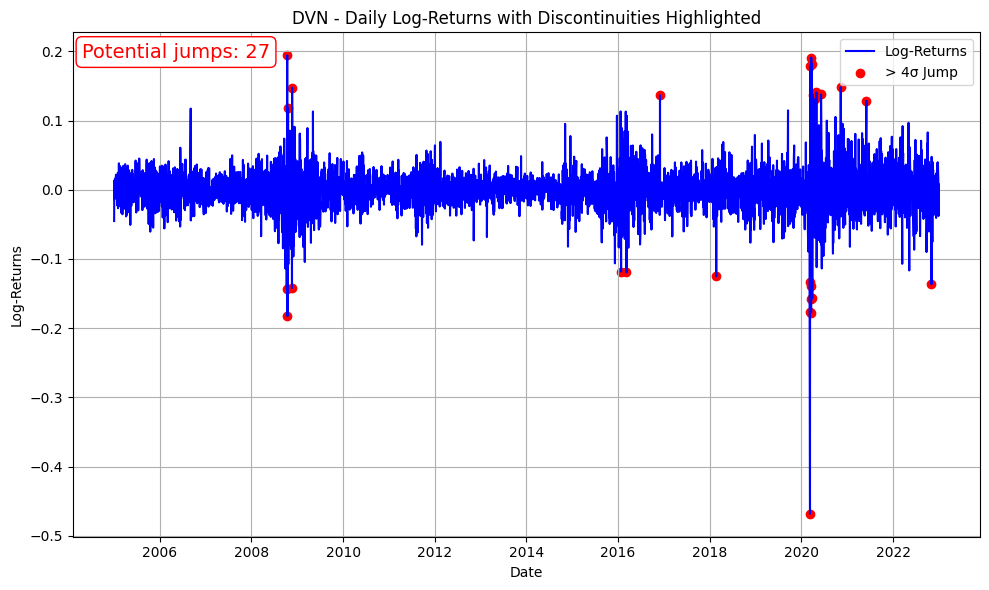

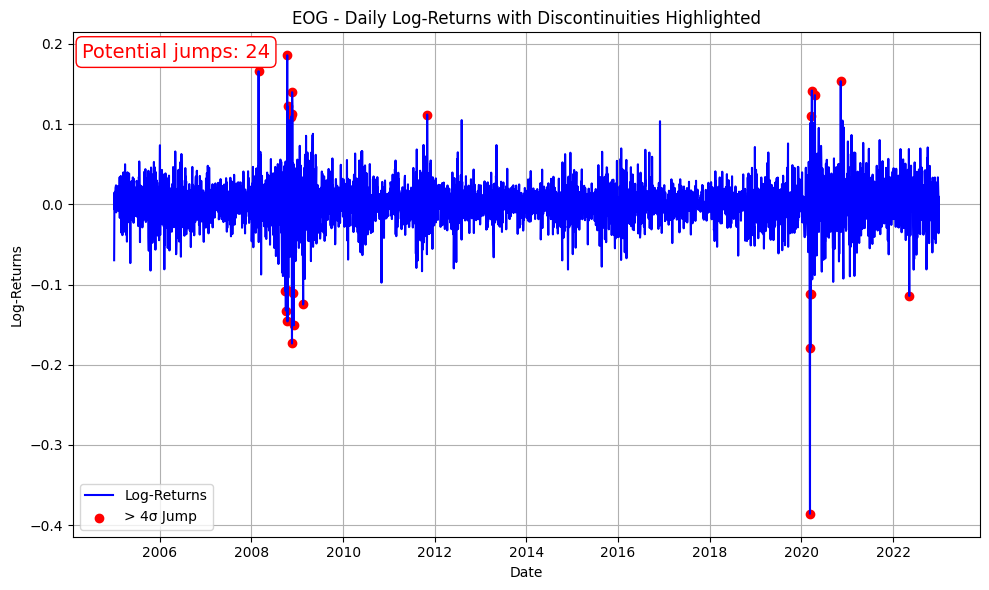

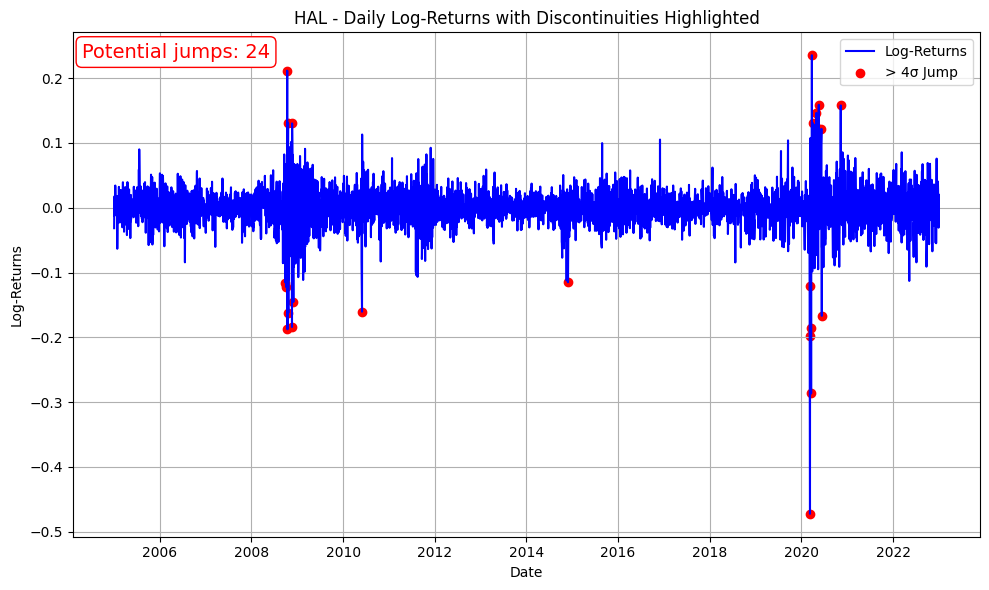

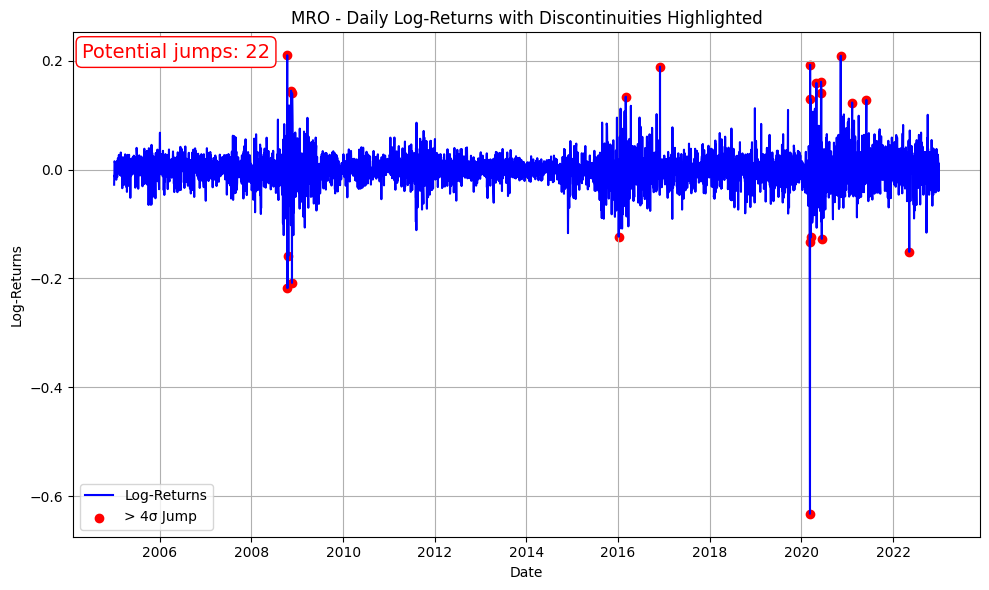

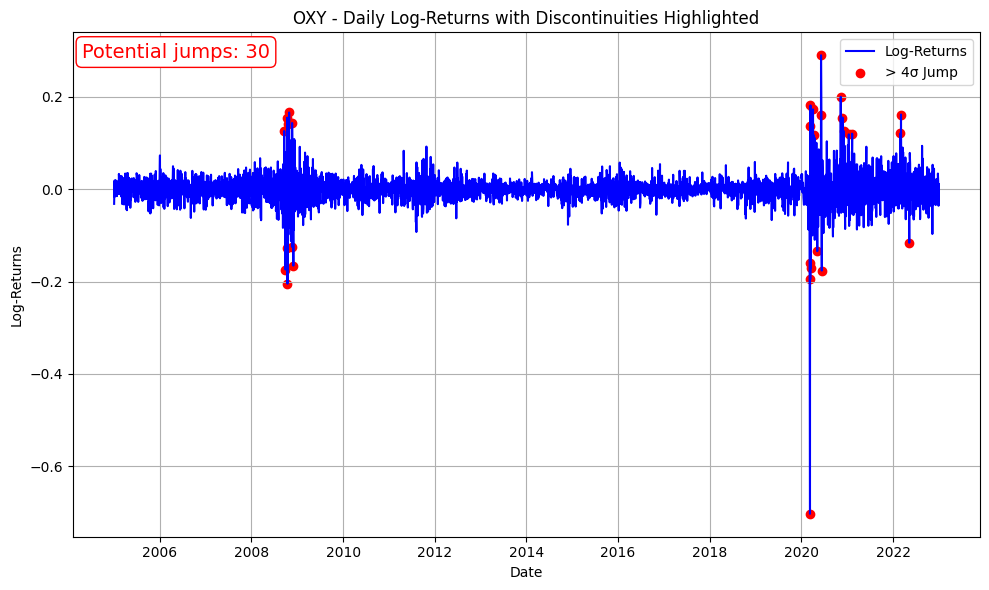

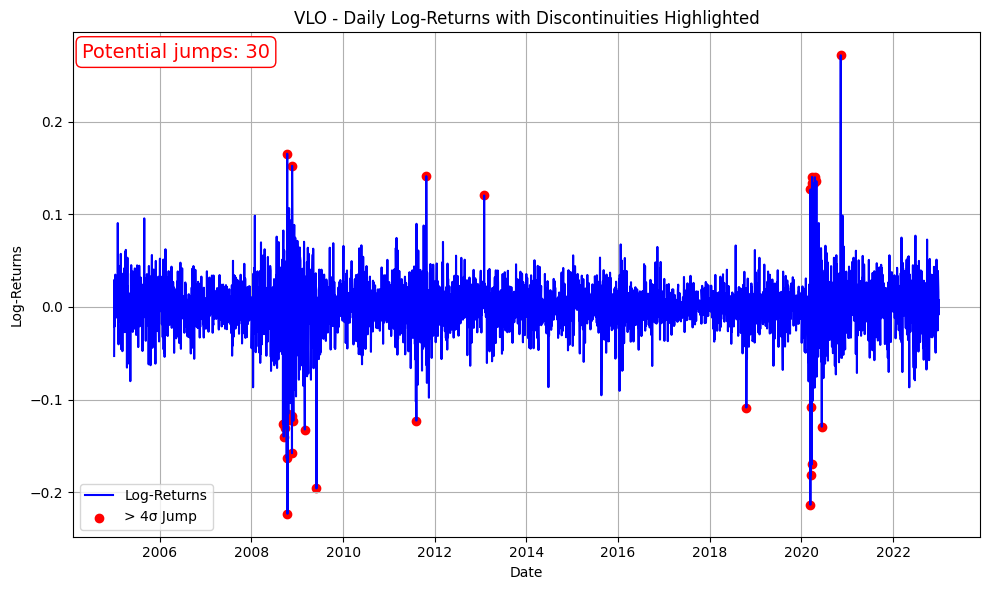

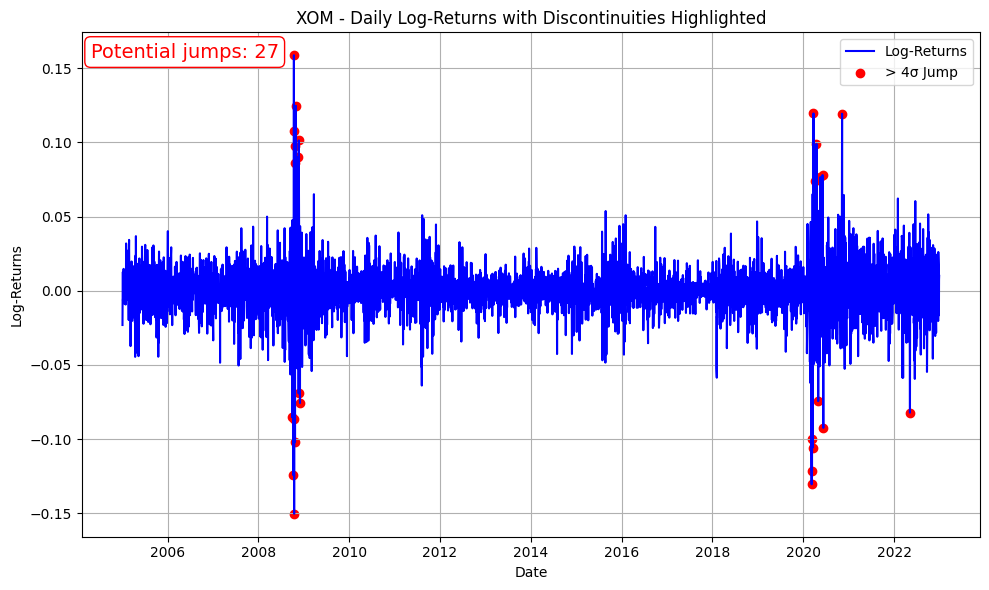

In [8]:
# Set threshold of standard deviations for jumps
k = 4

# Run loop per ticker
for t in tickers:
    # Call each dataframe per ticker
    df = ret_tickers[t]
    
    # Define mean
    mu = df['log_ret'].mean()
    # Define standard deviation
    sigma = df['log_ret'].std(ddof=1)
    # Define z-score
    df['z_score'] = (df['log_ret'] - mu) / sigma
    # Identify jumps
    jumps = df[np.abs(df['z_score']) > k]
    # Idenfity number of jumps
    n_jumps = len(jumps)
    
    # Plot each log-returns with jumps per ticker
    fig = plt.figure(figsize=(10,6))
    plt.plot(df['date'], df['log_ret'], label='Log-Returns', color='blue')
    plt.scatter(jumps['date'], jumps['log_ret'], color='red', label=f'> {k}σ Jump')

    # Set annotation
    plt.text(0.01, 0.95, f'Potential jumps: {n_jumps}', transform=plt.gca().transAxes,
             fontsize=14, color='red', bbox=dict(facecolor='white', edgecolor='red', boxstyle='round'))
    
    # Set axis labels
    plt.xlabel('Date')
    plt.ylabel('Log-Returns')
    
    # Set title
    plt.title(f'{t.upper()} - Daily Log-Returns with Discontinuities Highlighted')
    
    # Set grid
    plt.grid(True)
    
    # Set label
    plt.legend()
    
    # Set layout
    plt.tight_layout()
    
    # Save if requested
    if save_plt:
        # Create directory
        out_dir = Path("jump_log_ret")
        out_dir.mkdir(parents=True, exist_ok=True)
        # Save plot as a PNG file in a directory
        fname = f"{str(t).upper()}.png"                            # name of the PNG file (e.g. "APA")
        fig.savefig(out_dir / fname, dpi=300, bbox_inches="tight")
    
    # Show plots
    plt.show()
    plt.close(fig)

## Analyze Potential Jump Log-Returns Distribution (Fig. 3)

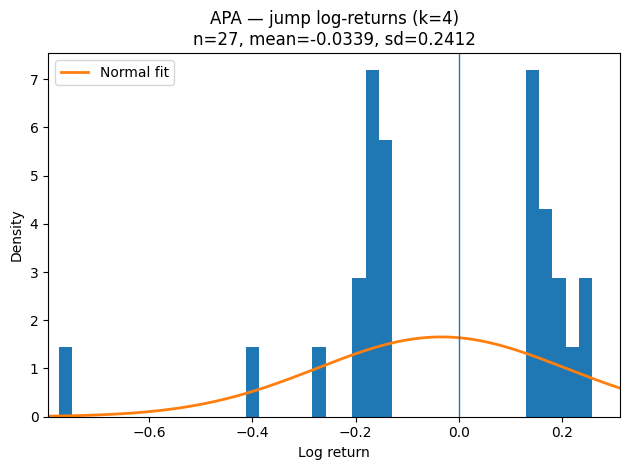

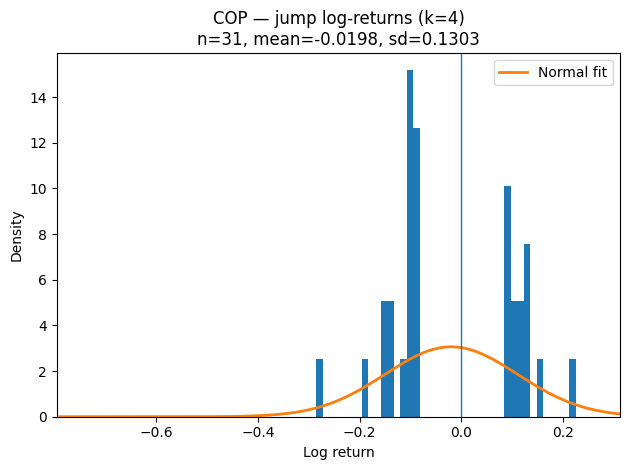

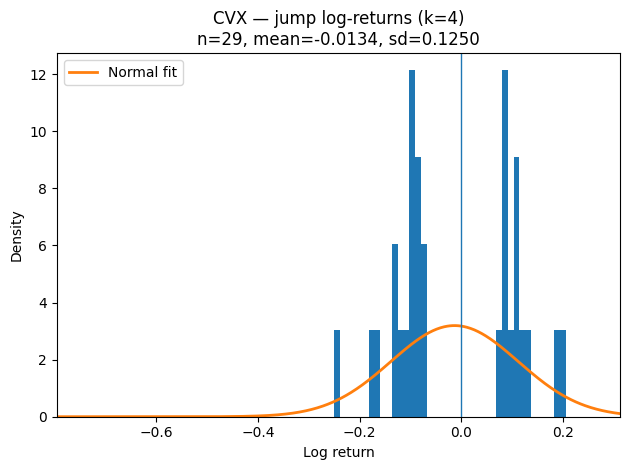

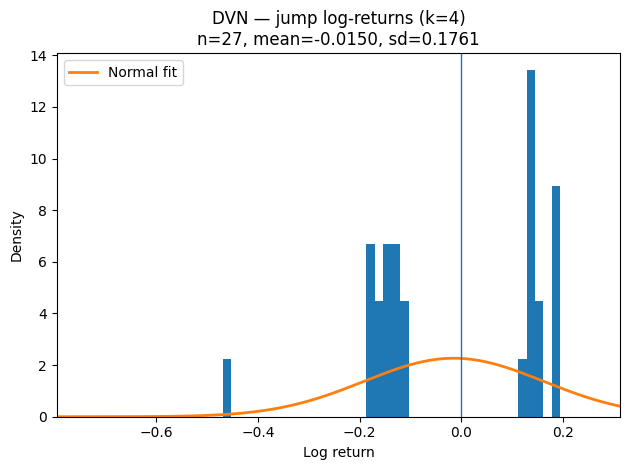

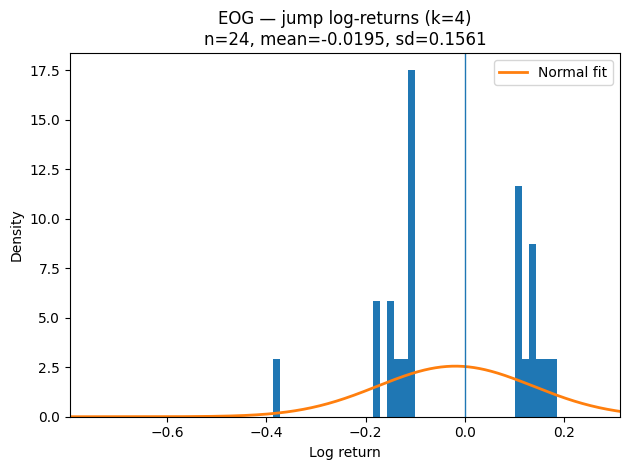

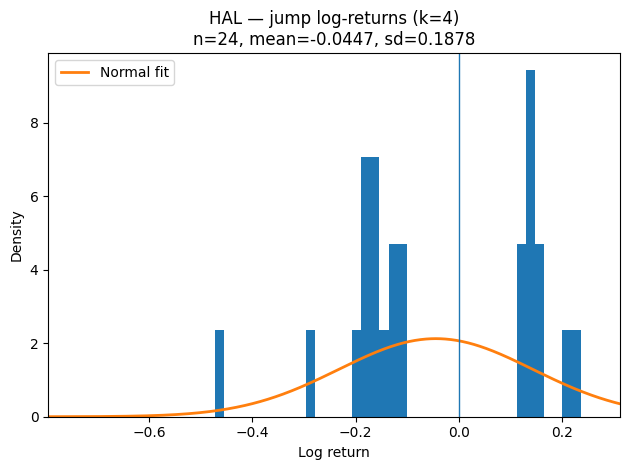

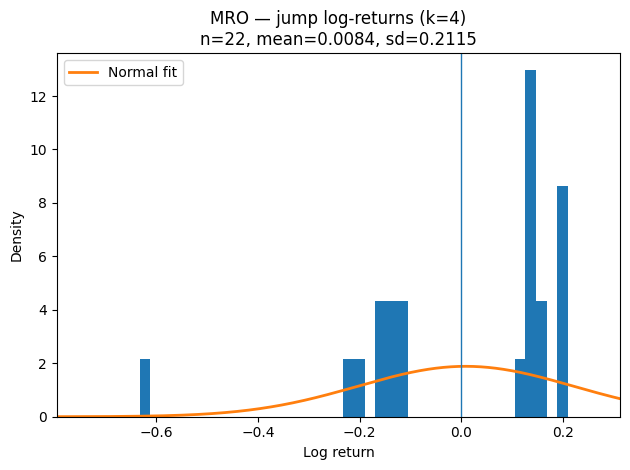

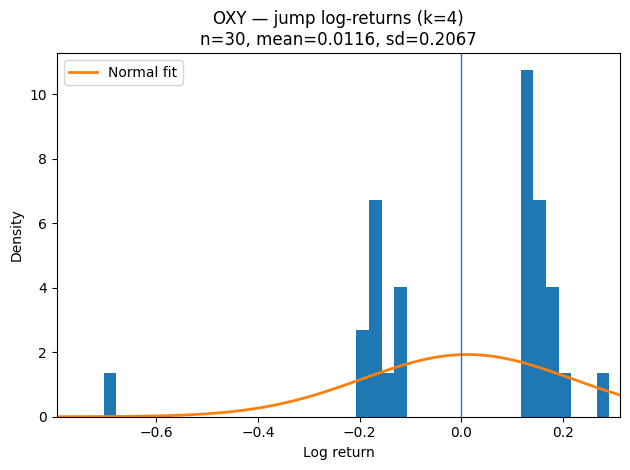

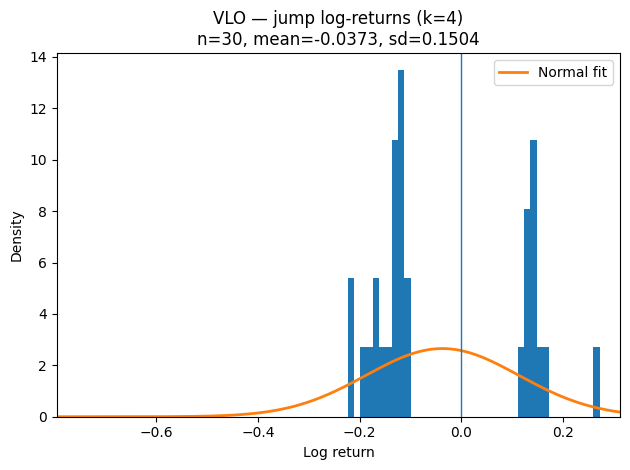

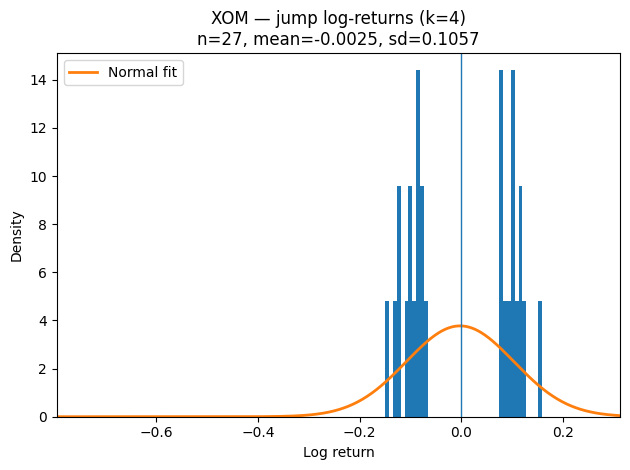

In [9]:
# List to collect jump log-returns
jumps_ret = []

# Run a loop to get jump stats and plot histogram
for t in tickers:
    # Call each dataframe per ticker
    df = ret_tickers[t]
    
    # Define mean
    mu = df['log_ret'].mean()
    # Define standard deviation
    sigma = df['log_ret'].std(ddof=1)
    # Define z-score
    df['z_score'] = (df['log_ret'] - mu) / sigma
    
    # Identify jumps
    jumps = df[np.abs(df['z_score']) > k]
    jumps_ret.append(jumps)
    
# Convert to dataframe
jumps_df = pd.concat(jumps_ret)
jumps_df = jumps_df[['ticker', 'date', 'log_ret', 'year']].copy()

# Define horizon of the plots
xmin = jumps_df['log_ret'].min()
xmax = jumps_df['log_ret'].max()
pad = 0.02 * (xmax - xmin) if np.isfinite(xmax - xmin) else 0.0
xmin_plot, xmax_plot = xmin - pad, xmax + pad

# Run loop for plotting one graph per ticker
for t, sub in jumps_df.groupby('ticker'):
    # Drop NA values
    data = sub['log_ret'].dropna()
    
    mu_hat = data.mean()      # Jump mean
    sd_hat = data.std(ddof=1) # Jump std
    
    # Define a normal pdf
    lo = min(xmin_plot, data.min())
    hi = max(xmax_plot, data.max())
    xgrid = np.linspace(lo, hi, 600)
    ypdf  = norm.pdf(xgrid, loc=mu_hat, scale=sd_hat)
    
    # Plot histogram with jump returns (log)
    fig = plt.figure()
    plt.hist(data, bins=40, density=True)
    # Plot a normal pdf line 
    plt.plot(xgrid, ypdf, linewidth=2, label="Normal fit")
    # Define zero with a vertical line
    plt.axvline(0.0, linewidth=1)
    plt.xlim(xmin_plot, xmax_plot)
    
    # Set axis labels
    plt.xlabel('Log return')
    plt.ylabel('Density')
    
    # Set title
    plt.title(
        f"{t} — jump log-returns (k={k})\n"
        f"n={len(data)}, mean={data.mean():.4f}, sd={data.std():.4f}"
    )
    
    # Set label
    plt.legend()
    
    # Set layout
    plt.tight_layout()
    
    # Save if requested
    if save_plt:
        # Create directory
        out_dir = Path("jump_hist")
        out_dir.mkdir(parents=True, exist_ok=True)
        # Save plot as a png
        fname = f"{str(t).upper()}.png"                            # name of the PNG file (e.g. "APA")
        fig.savefig(out_dir / fname, dpi=300, bbox_inches="tight") # place inside a folder
    
    # Show plots
    plt.show()
    plt.close(fig)

## Analyze dividends (Table 4)

In [10]:
# Get dividends data
ret_div = helper.crsp_dividends(tickers, start_year, end_year)

# Analyze number of dividends and average amount paid per year
div_stats = (
    ret_div
    .groupby(['ticker', 'ex_year'], as_index=False)
    .agg(
        num_dividends=('div_per_share', 'count'),
        avg_dividend=('div_per_share', 'mean')
        )
)

div_stats["avg_dividend"] = div_stats["avg_dividend"].round(2)

# Save if required
if save_table:
    # Save if required
    div_stats.to_csv("dividends.csv", index=False)

# Loop to visualize all tickers data
for t in tickers:
    print('\n')
    print(div_stats[div_stats['ticker'] == t])



   ticker  ex_year  num_dividends  avg_dividend
0     APA     2005              4          0.08
1     APA     2006              4          0.11
2     APA     2007              4          0.15
3     APA     2008              4          0.15
4     APA     2009              4          0.15
5     APA     2010              4          0.15
6     APA     2011              4          0.15
7     APA     2012              4          0.16
8     APA     2013              4          0.19
9     APA     2014              4          0.24
10    APA     2015              4          0.25
11    APA     2016              4          0.25
12    APA     2017              4          0.25
13    APA     2018              4          0.25
14    APA     2019              4          0.25
15    APA     2020              4          0.08
16    APA     2021              4          0.03
17    APA     2022              4          0.16


   ticker  ex_year  num_dividends  avg_dividend
18    COP     2005              4   